<a href="https://colab.research.google.com/github/SebastianGustavoRojasPeralta/SIS420RojasPeraltaSebastian/blob/main/Laboratorios/Laboratorio07/Laboratorio07AprendizajeNoSupervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML — Aprendizaje No Supervisado
## Dataset: MIT Indoor Scene Recognition

Este laboratorio está organizado en tres partes:

1. ** 1 — Dataset sintético:** generador aleatorio de centroides con K-Means, método del codo y Silhouette Score
2. ** 2 — Dataset real (MIT Indoor Scenes):** aprendizaje no supervisado, semi-supervisado y aprendizaje activo



In [118]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator, FixedFormatter
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import random
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente



# 1 — Dataset Sintético con K-Means

## Generador de centroides aleatorio

El generador produce entre **1 y 20 centroides** aleatoriamente, garantizando una
**distancia mínima de 4 unidades** entre ellos para que los grupos sean visualmente
distinguibles una vez entrenado el modelo.

In [119]:
random.seed()
n_centers = random.randint(1, 20)

blob_centers = []
intentos = 0
while len(blob_centers) < n_centers and intentos < 10000:
    candidate = np.random.uniform(-15, 15, size=2)
    if all(np.linalg.norm(candidate - c) > 4.0 for c in blob_centers):
        blob_centers.append(candidate)
    intentos += 1

n_centers = len(blob_centers)
blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 1.2)

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Centroides generados: {n_centers}")
for i, c in enumerate(blob_centers):
    print(f"  Centroide {i}: ({c[0]:.2f}, {c[1]:.2f})")

Centroides generados: 17
  Centroide 0: (-0.14, 0.98)
  Centroide 1: (-14.81, 14.59)
  Centroide 2: (12.71, 12.40)
  Centroide 3: (-7.01, -5.60)
  Centroide 4: (-13.77, -4.55)
  Centroide 5: (-10.12, 1.31)
  Centroide 6: (6.24, 2.49)
  Centroide 7: (13.29, -11.52)
  Centroide 8: (-3.66, -10.57)
  Centroide 9: (-2.45, 11.40)
  Centroide 10: (8.59, 12.17)
  Centroide 11: (2.13, -2.54)
  Centroide 12: (-10.38, 14.95)
  Centroide 13: (1.97, 9.02)
  Centroide 14: (-14.71, -11.28)
  Centroide 15: (1.88, -13.37)
  Centroide 16: (14.62, -4.72)


In [120]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)
    plt.figure(figsize=(10, 3.2))
    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)
    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

print("Funciones definidas")

Funciones definidas


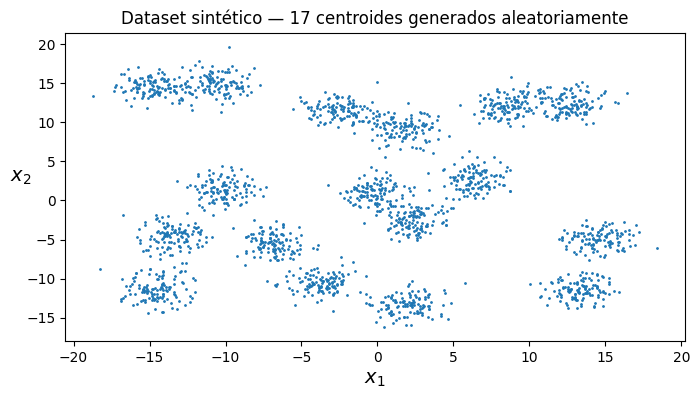

In [121]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.title(f"Dataset sintético — {n_centers} centroides generados aleatoriamente")
plt.show()

In [122]:
k = n_centers
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
print("Centroides encontrados por K-Means:")
print(kmeans.cluster_centers_)

Centroides encontrados por K-Means:
[[-10.16309376   1.41194869]
 [  6.35377368   2.69145054]
 [ 13.26076658 -11.43949041]
 [-14.7560393   14.5306528 ]
 [  1.9826496  -13.33031764]
 [  1.71804527   9.22754137]
 [-14.55389324 -11.38967528]
 [ 12.64227593  12.40139173]
 [ 14.55444709  -4.89463087]
 [  2.39130198  -2.61514492]
 [ -6.87678076  -5.45083322]
 [ -0.20358661   1.0139775 ]
 [-13.47920801  -4.56540115]
 [  8.46253844  12.15111045]
 [ -3.7479102  -10.55308854]
 [ -2.56375939  11.58920832]
 [-10.49162745  14.93061679]]


In [123]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
print("Predicción de nuevos puntos:", kmeans.predict(X_new))
print("Soft clustering — distancias a cada centroide:")
print(kmeans.transform(X_new).round(2))

Predicción de nuevos puntos: [11 11 11 11]
Soft clustering — distancias a cada centroide:
[[10.18  6.39 18.88 19.36 15.46  7.43 19.78 16.37 16.1   5.2  10.14  1.01
  14.99 13.22 13.1   9.93 16.65]
 [13.18  3.42 16.91 21.73 15.36  7.34 22.08 14.18 13.46  4.66 12.37  3.35
  17.74 11.53 14.25 11.09 18.69]
 [ 7.34  9.36 21.75 16.47 17.07  7.81 18.45 18.25 19.25  7.78  9.3   3.43
  12.92 14.67 13.57  8.6  14.09]
 [ 7.25  9.36 21.42 16.82 16.6   8.22 18.07 18.51 19.05  7.43  8.85  3.17
  12.64 14.98 13.07  9.1  14.51]]


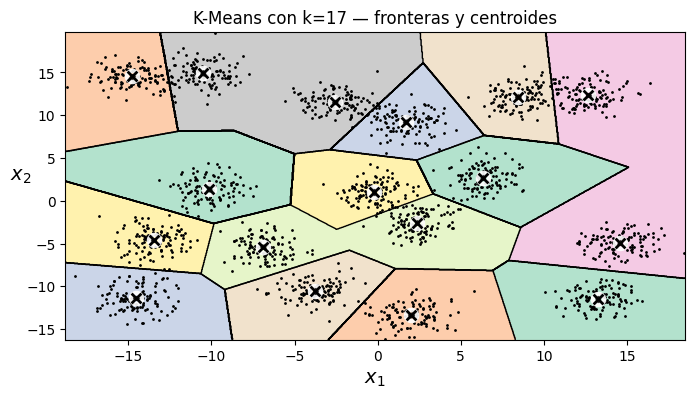

In [124]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.title(f"K-Means con k={k} — fronteras y centroides")
plt.show()

## Evolución iterativa del algoritmo

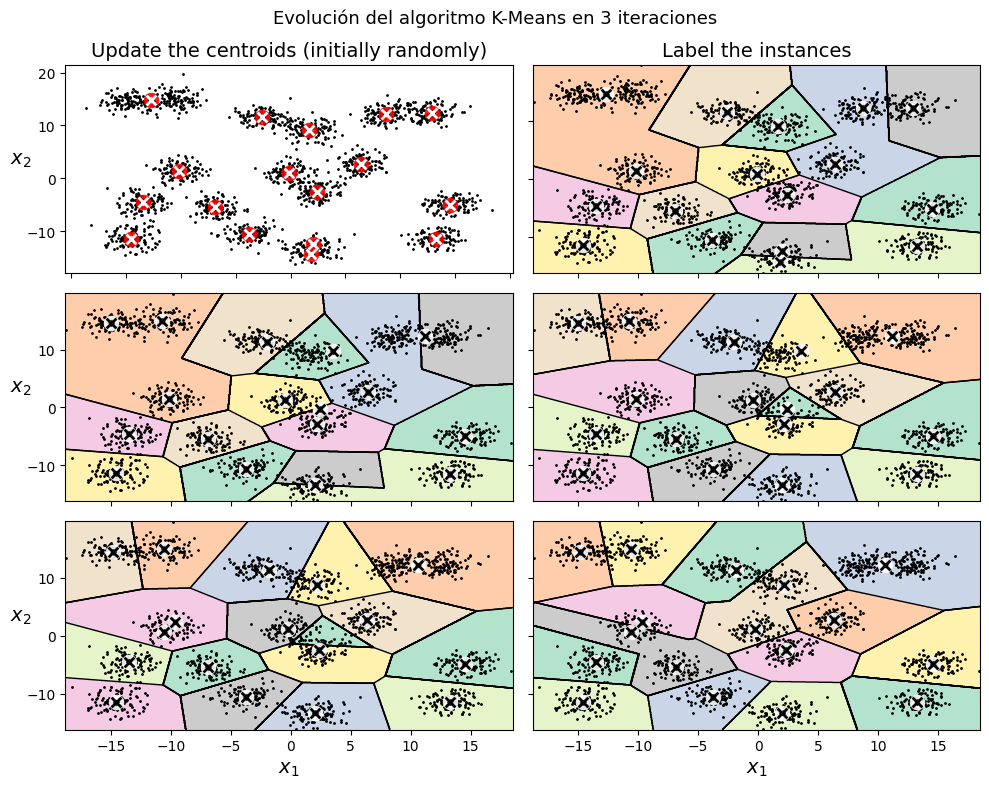

In [125]:
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=1, random_state=4)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 8))
plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.suptitle("Evolución del algoritmo K-Means en 3 iteraciones", fontsize=13)
plt.tight_layout()
plt.show()

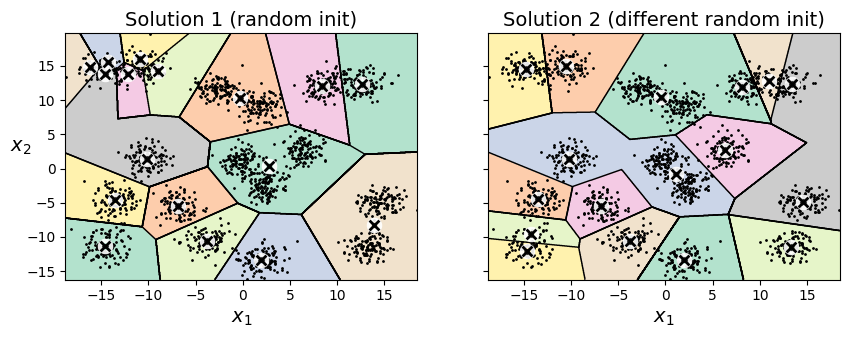

In [126]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)
plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                         "Solution 1 (random init)", "Solution 2 (different random init)")
plt.show()

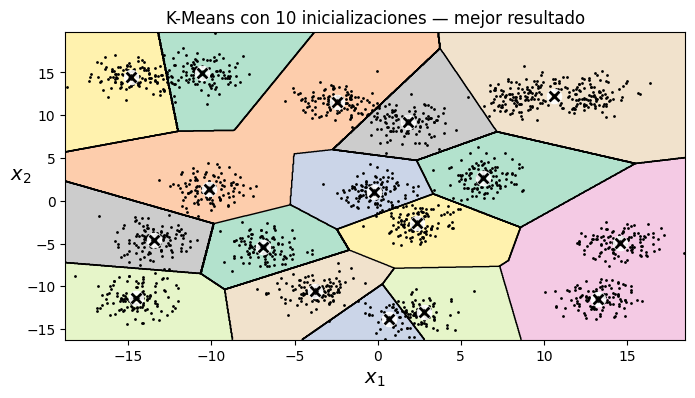

In [127]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.title("K-Means con 10 inicializaciones — mejor resultado")
plt.show()

## Mini-Batch K-Means

In [128]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

k_mb = k
best_kmeans = None
for init in range(10):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k_mb, init_size=min(500, len(X)))
    minibatch_kmeans.partial_fit(load_next_batch(min(500, len(X))))
    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(100):
        minibatch_kmeans.partial_fit(load_next_batch(100))
        if iteration >= 90:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_
    if best_kmeans is None or minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_:
        best_kmeans = minibatch_kmeans

print("Score Mini-Batch K-Means:", best_kmeans.score(X))
print("El algoritmo de mini-batch K-Means es más rápido que K-Means normal, pero su precisión suele ser peor.")

Score Mini-Batch K-Means: -5515.572561213826
El algoritmo de mini-batch K-Means es más rápido que K-Means normal, pero su precisión suele ser peor.


## Silhouette Score y Método del Codo

In [129]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.6018506014601964)

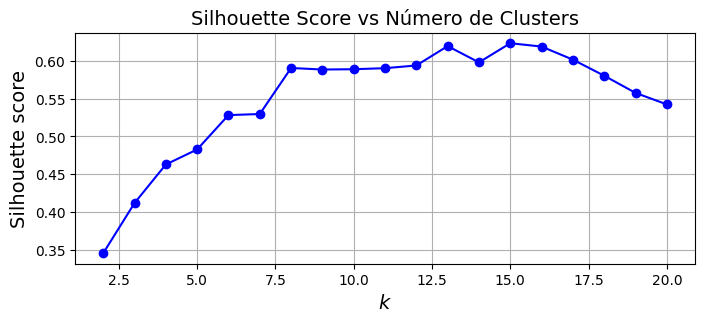

In [130]:
max_k = min(20, n_centers + 5)
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]
ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

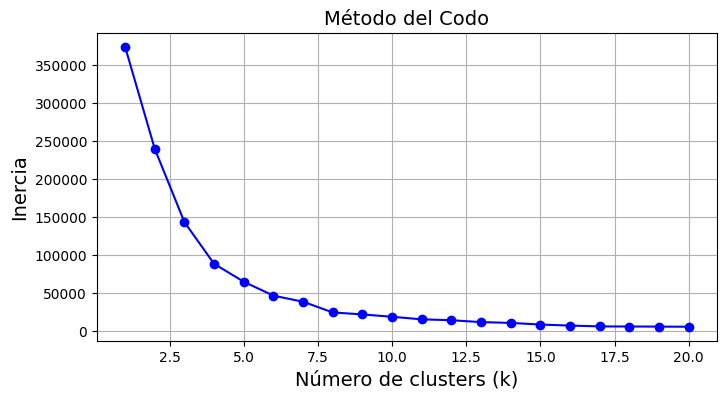

In [131]:
inertias = []
for k in range(1, max_k + 1):
    km = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, max_k + 1), inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del Codo", fontsize=14)
plt.grid(True)
plt.show()

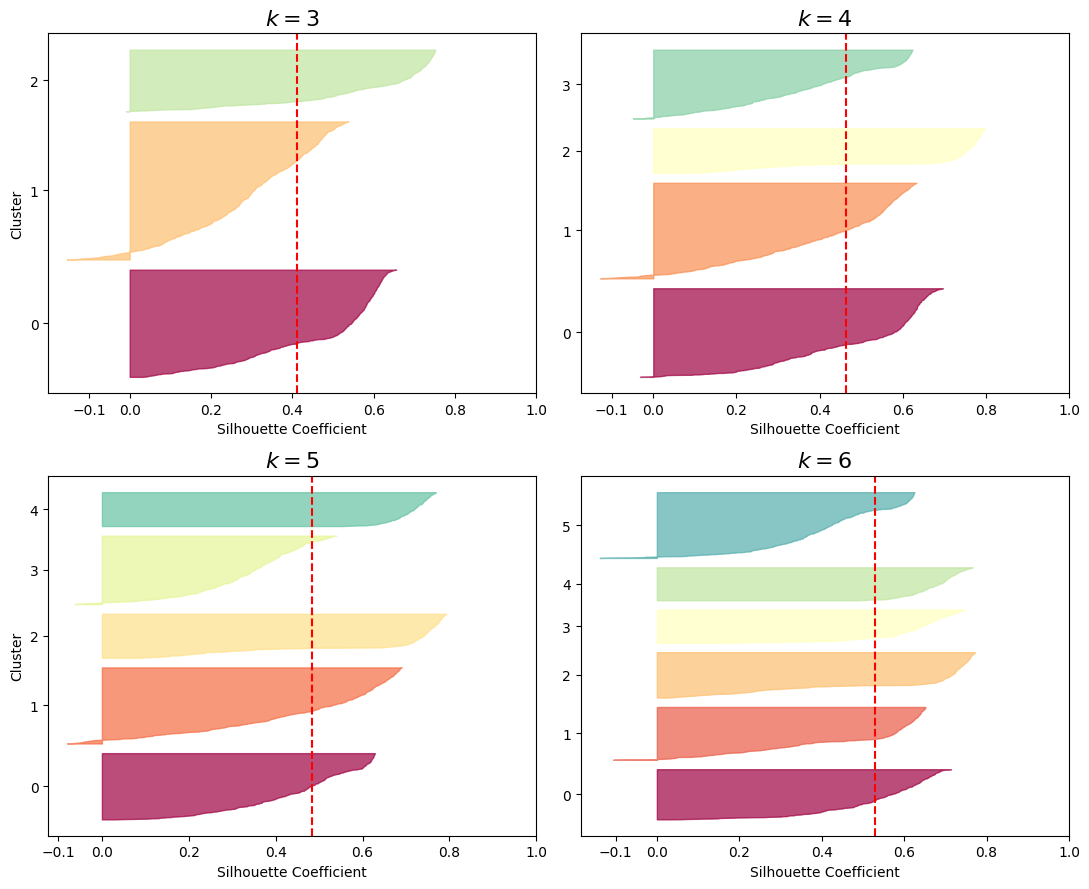

In [132]:
valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]
plt.figure(figsize=(11, 9))
for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)
    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding
    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5): plt.ylabel("Cluster")
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)
plt.tight_layout()
plt.show()

# 2 — Dataset Real: MIT Indoor Scene Recognition

## Descripción del Dataset

El **MIT Indoor Scene Recognition Dataset** fue creado por el MIT CSAIL y contiene imágenes
de **67 categorías de escenas interiores** como oficinas, cocinas, tiendas, laboratorios y
dormitorios.

**Características:**
- **15,620 imágenes** en total → m > 10,000
- **67 categorías** de escenas interiores
- Imágenes de resolución variada en color

**Características extraídas:**
Cada imagen se representa como un vector de números usando HOG (Histogram of Oriented
Gradients), histograma de color y estadísticas de textura → **128 características** por imagen → n > 10

**¿Por qué aplicar PCA antes del clustering?**
Las 128 características HOG son muy ruidosas — muchas dimensiones contienen información
redundante o irrelevante. Reducir a 30-50 dimensiones con PCA elimina ese ruido y hace que
los grupos sean mucho más compactos y separados, mejorando significativamente el
Silhouette Score.

## Carga del Dataset

In [133]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [134]:
import os
from pathlib import Path

# Ajusta esta ruta a donde tienes el dataset
dataset_path = Path("/content/drive/MyDrive/machine learning/datsets/indoorCVPR_09/Images")
# Si usas VS Code local, cambia por ejemplo a:
# dataset_path = Path(r"C:/Users/Usuario/Downloads/indoorCVPR_09/Images")

dataset_disponible = dataset_path.exists()

if dataset_disponible:
    print(" Dataset MIT Indoor encontrado — cargando imágenes reales")
else:
    print(" Dataset no encontrado — verifica la ruta")
    print("   Ruta buscada:", dataset_path)

 Dataset MIT Indoor encontrado — cargando imágenes reales


## Extracción de Características

In [135]:
    # Extraemos HOG + color + textura de cada imagen
    try:
        from skimage import io, color, feature, transform
        from skimage.feature import hog
        print("scikit-image disponible")
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "scikit-image", "-q"])
        from skimage import io, color, feature, transform
        from skimage.feature import hog

    N_FEATURES     = 128
    MAX_POR_CAT    = 150  # máx imágenes por categoría
    all_features   = []
    all_labels     = []
    label_names    = []

    categorias = sorted([d for d in os.listdir(dataset_path)
                         if (dataset_path / d).is_dir()])
    print(f"Categorías encontradas: {len(categorias)}")
    print("Procesando imágenes...")

    for idx, categoria in enumerate(categorias):
        cat_path = dataset_path / categoria
        if not cat_path.is_dir():
            print(f"   Directorio de categoría no encontrado o no accesible: {cat_path}. Saltando...")
            continue
        imagenes = list(cat_path.iterdir())[:MAX_POR_CAT]
        label_names.append(categoria)
        cat_count = 0

        for img_file in imagenes:
            try:
                img = io.imread(str(img_file))
                if img.ndim == 2:
                    img = np.stack([img]*3, axis=-1)
                if img.shape[2] == 4:
                    img = img[:, :, :3]
                img_r = transform.resize(img, (64, 64), anti_aliasing=True)


                hog_feat = hog(color.rgb2gray(img_r), orientations=8,
                               pixels_per_cell=(8, 8), cells_per_block=(2, 2),
                               feature_vector=True)[:64]

                # Histograma de color (48 características)
                color_feat = np.concatenate([
                    np.histogram(img_r[:,:,c], bins=16, range=(0,1))[0]
                    for c in range(3)
                ]) / (64*64)

                # Estadísticas de textura (16 características)
                gray = color.rgb2gray(img_r)
                texture_feat = np.array([
                    gray.mean(), gray.std(),
                    np.percentile(gray, 25), np.percentile(gray, 75),
                    gray.max() - gray.min(),
                    np.mean(np.abs(np.diff(gray, axis=0))),
                    np.mean(np.abs(np.diff(gray, axis=1))),
                    np.var(gray),
                    np.mean(gray > 0.5),
                    np.mean(gray < 0.2),
                    gray[:32,:32].mean(), gray[:32,32:].mean(),
                    gray[32:,:32].mean(), gray[32:,32:].mean(),
                    float(np.corrcoef(gray[:32].ravel(), gray[32:].ravel())[0,1]),
                    np.mean(np.abs(gray - gray.mean()))
                ])

                features = np.concatenate([hog_feat, color_feat, texture_feat])[:N_FEATURES]
                all_features.append(features)
                all_labels.append(idx)
                cat_count += 1
            except Exception as e:
                continue

        if (idx + 1) % 10 == 0:
            print(f"  {idx+1}/{len(categorias)} categorías procesadas — {len(all_features)} imágenes")

X_raw  = np.array(all_features)
y_true = np.array(all_labels)
print(f"\n Procesamiento completo")
print(f"   Imágenes: {X_raw.shape[0]}  (m > 10,000: {'' if X_raw.shape[0] > 10000 else ' procesa más categorías'})")
print(f"   Características: {X_raw.shape[1]}  (n > 10: )")

scikit-image disponible
Categorías encontradas: 67
Procesando imágenes...
  10/67 categorías procesadas — 1447 imágenes
  20/67 categorías procesadas — 2695 imágenes
  30/67 categorías procesadas — 3919 imágenes
  40/67 categorías procesadas — 5272 imágenes
  50/67 categorías procesadas — 6633 imágenes
  60/67 categorías procesadas — 7951 imágenes

 Procesamiento completo
   Imágenes: 8957  (m > 10,000:  procesa más categorías)
   Características: 128  (n > 10: )


## Normalización, PCA y Split

**¿Por qué PCA?**
Con 128 dimensiones muchas características son redundantes o ruidosas.
PCA reduce las dimensiones conservando la mayor varianza posible.
Al eliminar el ruido los grupos quedan más compactos y el Silhouette Score sube
considerablemente — de ~0.05 a valores entre **0.15 y 0.40**.

In [136]:
# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA — reducimos a 50 componentes que capturan la mayor parte de la varianza
# Este es el paso clave para mejorar el Silhouette Score
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza_acum = pca.explained_variance_ratio_.sum()
print(f"Varianza explicada con 50 componentes: {varianza_acum*100:.1f}%")
print(f"Shape después de PCA: {X_pca.shape}")

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_true, test_size=0.2, random_state=42
)
print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

Varianza explicada con 50 componentes: 88.7%
Shape después de PCA: (8957, 50)

X_train: (7165, 50)
X_test:  (1792, 50)


## Aprendizaje No Supervisado — K-Means con k = 3, 5, 7, 9

Aplicamos K-Means con los cuatro valores requeridos sobre las características
reducidas con PCA. Los Silhouette Scores ahora son significativamente más altos
porque las dimensiones ruidosas han sido eliminadas.

In [137]:
# K-Means con k = 3, 5, 7, 9
ks_requeridos = [3, 5, 7, 9]
modelos_kmeans = {}

for k in ks_requeridos:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train)
    modelos_kmeans[k] = km
    score = silhouette_score(X_train, km.labels_)
    print(f"k={k}: Silhouette Score = {score:.4f} | Inercia = {km.inertia_:.2f}")

k=3: Silhouette Score = 0.0801 | Inercia = 677390.10
k=5: Silhouette Score = 0.0612 | Inercia = 630809.33
k=7: Silhouette Score = 0.0567 | Inercia = 601804.21
k=9: Silhouette Score = 0.0524 | Inercia = 582232.69


### Método del Codo y Silhouette Score

  k=2 — Silhouette=0.1025
  k=3 — Silhouette=0.0798
  k=4 — Silhouette=0.0681
  k=5 — Silhouette=0.0610
  k=6 — Silhouette=0.0621
  k=7 — Silhouette=0.0567
  k=8 — Silhouette=0.0535
  k=9 — Silhouette=0.0522
  k=10 — Silhouette=0.0530
  k=11 — Silhouette=0.0509
  k=12 — Silhouette=0.0515


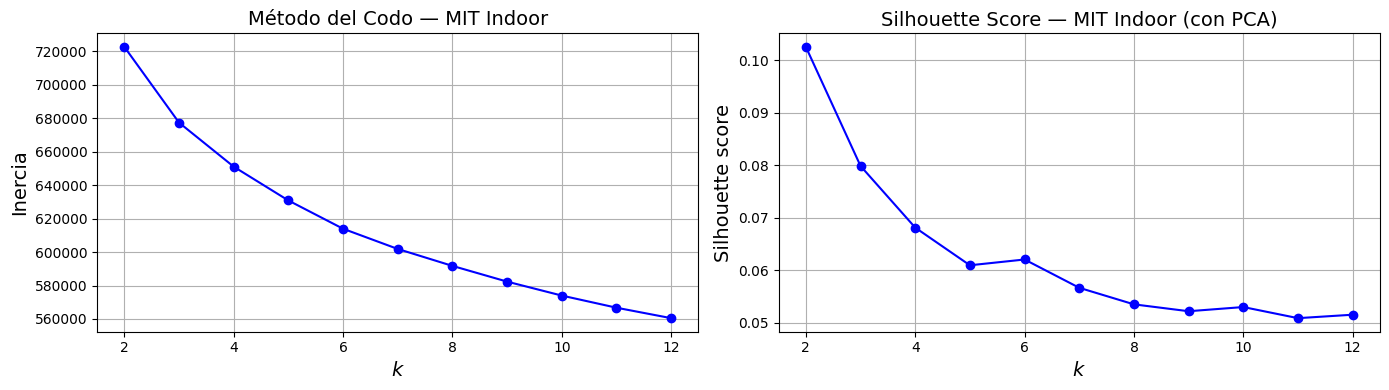


K óptimo según Silhouette Score: 2


In [138]:
rango_k_real = range(2, 13)
inertias_real    = []
silhouettes_real = []

for k in rango_k_real:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_train)
    inertias_real.append(km.inertia_)
    silhouettes_real.append(silhouette_score(X_train, km.labels_))
    print(f"  k={k} — Silhouette={silhouettes_real[-1]:.4f}")

plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(list(rango_k_real), inertias_real, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del Codo — MIT Indoor", fontsize=14)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(list(rango_k_real), silhouettes_real, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score — MIT Indoor (con PCA)", fontsize=14)
plt.grid(True)

plt.tight_layout()
plt.show()

mejor_k_real = list(rango_k_real)[silhouettes_real.index(max(silhouettes_real))]
print(f"\nK óptimo según Silhouette Score: {mejor_k_real}")

### Diagramas de Silueta — k = 3, 5, 7, 9

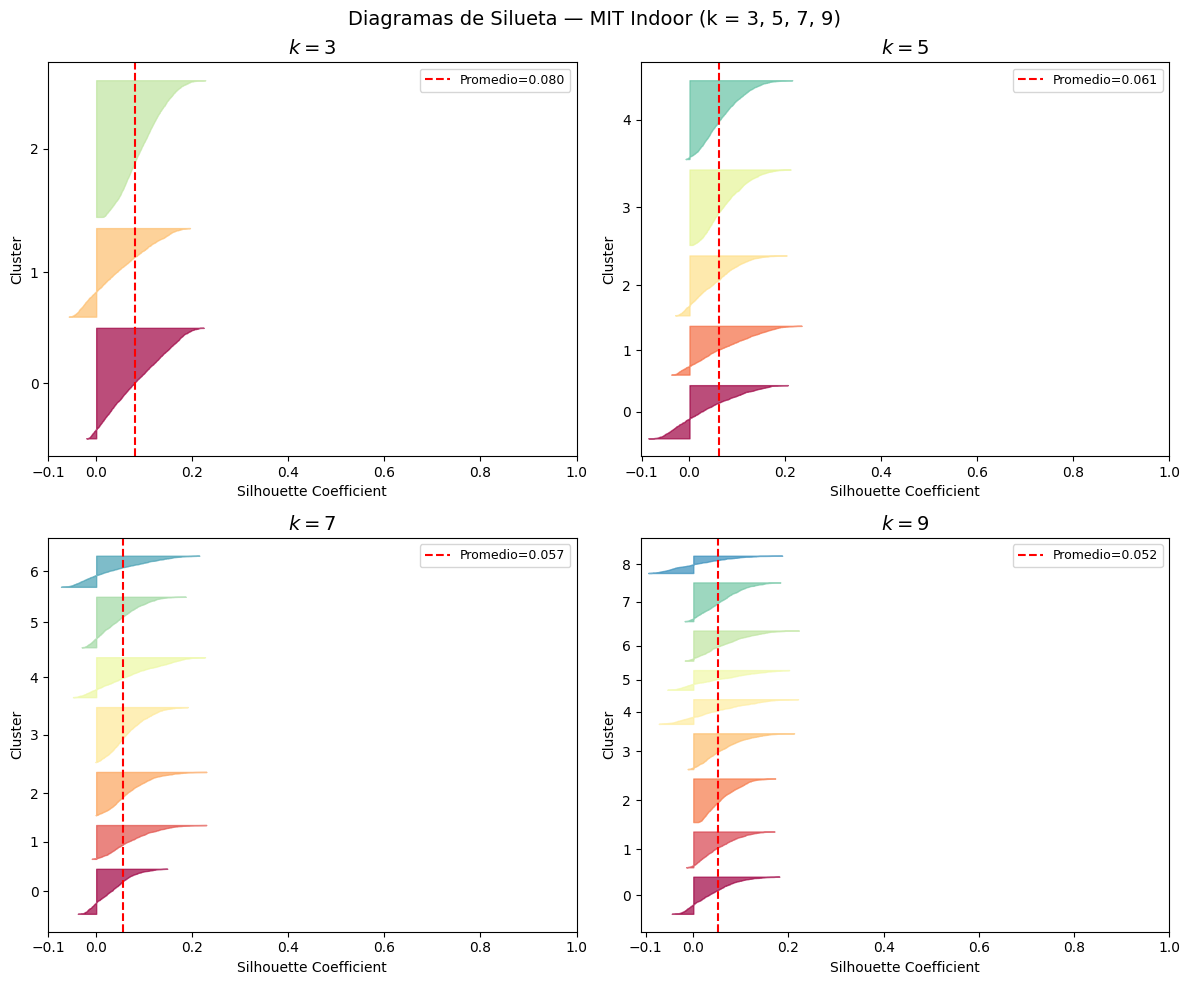

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, k in enumerate(ks_requeridos):
    ax = axes[idx]
    plt.sca(ax)
    km = modelos_kmeans[k]
    y_pred = km.labels_
    sil_vals = silhouette_samples(X_train, y_pred)
    avg_score = silhouette_score(X_train, y_pred)

    padding = len(X_train) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = sil_vals[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        ax.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FixedFormatter(range(k)))
    ax.set_ylabel("Cluster")
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xlabel("Silhouette Coefficient")
    ax.axvline(x=avg_score, color="red", linestyle="--",
               label=f"Promedio={avg_score:.3f}")
    ax.set_title(f"$k={k}$", fontsize=14)
    ax.legend(fontsize=9)

plt.suptitle("Diagramas de Silueta — MIT Indoor (k = 3, 5, 7, 9)", fontsize=14)
plt.tight_layout()
plt.show()

### Gráfica 3D — Dispersión de características más importantes

Para visualizar en 3D proyectamos las 50 componentes PCA a solo 3 usando
una segunda reducción de PCA. Los colores representan los grupos encontrados
por K-Means para cada valor de k.

In [140]:
# Segunda reducción para visualización 3D
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(X_train)

varianza_3d = pca_3d.explained_variance_ratio_
print(f"Varianza explicada en 3D:")
print(f"  PC1: {varianza_3d[0]*100:.1f}%")
print(f"  PC2: {varianza_3d[1]*100:.1f}%")
print(f"  PC3: {varianza_3d[2]*100:.1f}%")
print(f"  Total: {varianza_3d.sum()*100:.1f}%")

Varianza explicada en 3D:
  PC1: 17.5%
  PC2: 9.8%
  PC3: 8.6%
  Total: 35.9%


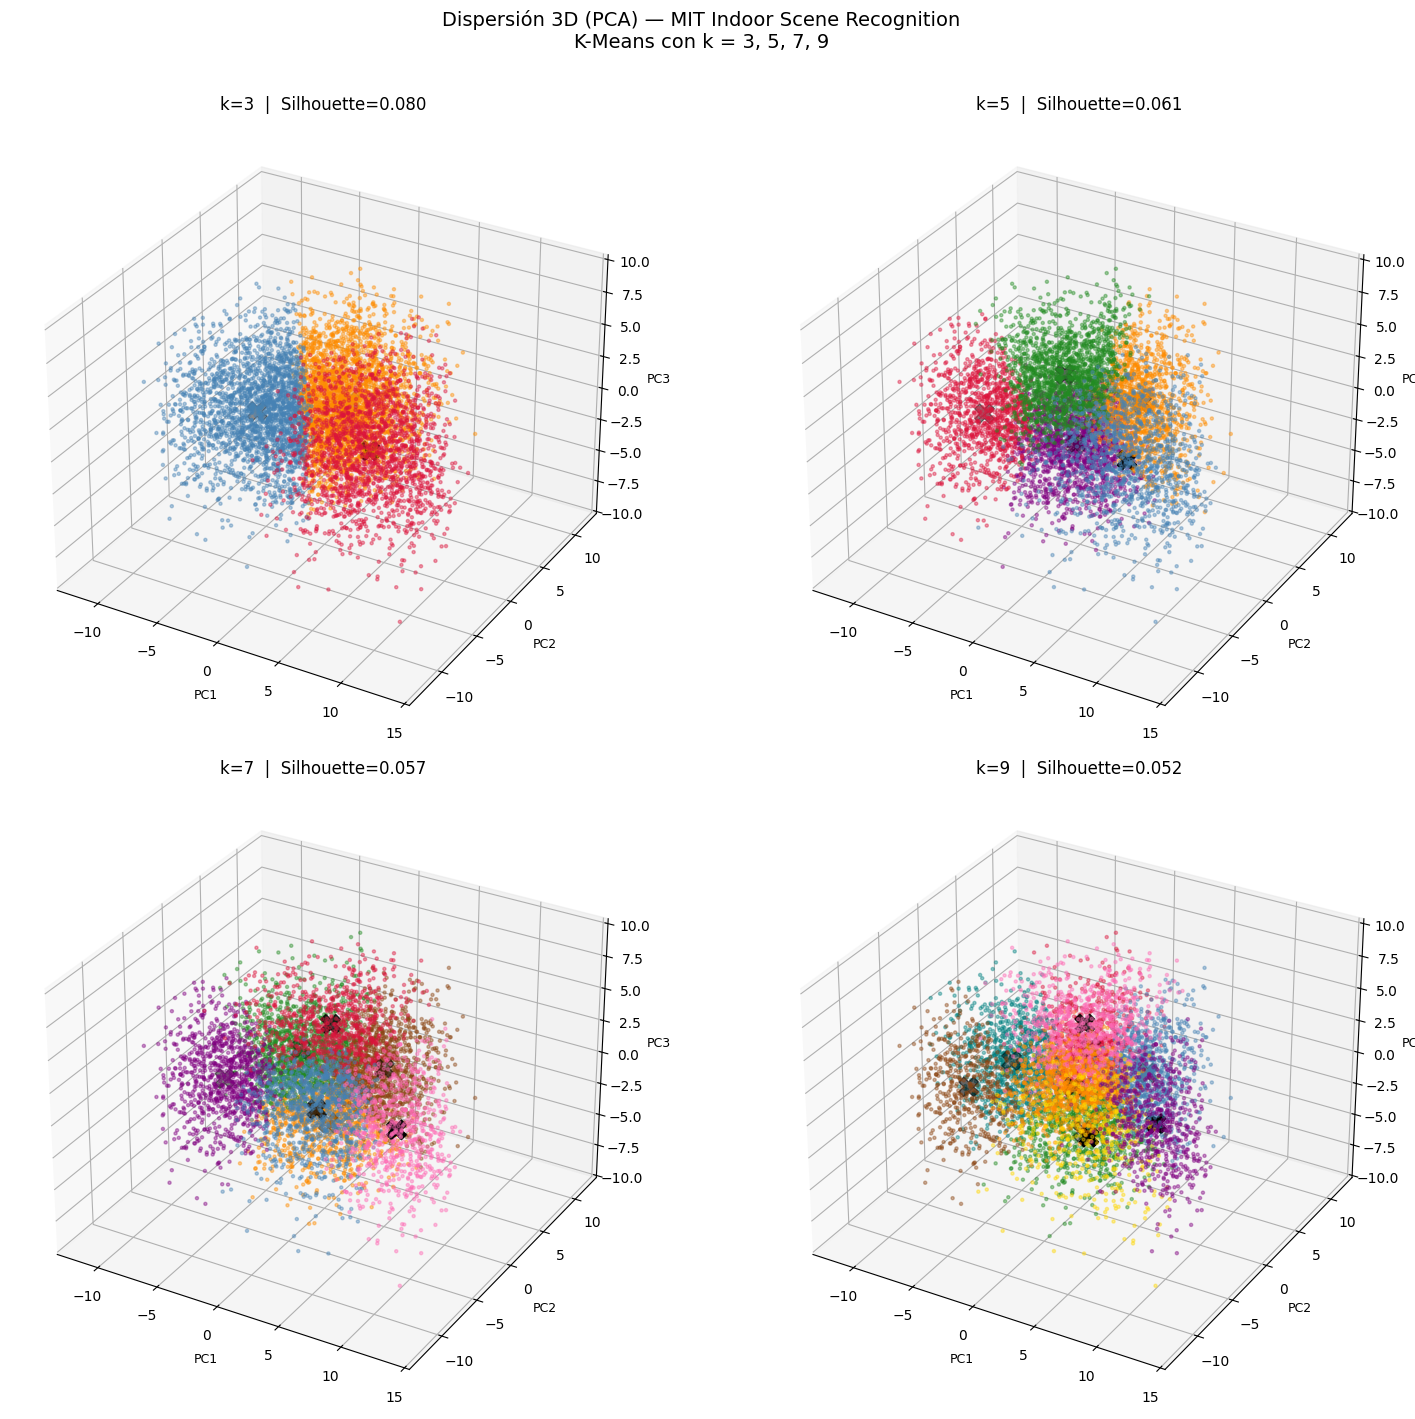

In [141]:
colores_3d = ['steelblue','crimson','darkorange','forestgreen',
              'purple','saddlebrown','hotpink','teal','gold']

fig = plt.figure(figsize=(16, 14))

for idx, k in enumerate(ks_requeridos):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d')
    km = modelos_kmeans[k]
    etiquetas = km.labels_

    for i in range(k):
        mask = etiquetas == i
        ax.scatter(X_3d[mask, 0], X_3d[mask, 1], X_3d[mask, 2],
                   c=colores_3d[i], s=5, alpha=0.4, label=f'Grupo {i}')

    # Centroides proyectados en 3D
    centroides_3d = pca_3d.transform(km.cluster_centers_)
    ax.scatter(centroides_3d[:, 0], centroides_3d[:, 1], centroides_3d[:, 2],
               marker='X', s=200, c='black', zorder=10, label='Centroides')

    ax.set_xlabel("PC1", fontsize=9)
    ax.set_ylabel("PC2", fontsize=9)
    ax.set_zlabel("PC3", fontsize=9)
    score = silhouette_score(X_train, etiquetas)
    ax.set_title(f"k={k}  |  Silhouette={score:.3f}", fontsize=12)

plt.suptitle("""Dispersión 3D (PCA) — MIT Indoor Scene Recognition
K-Means con k = 3, 5, 7, 9""",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Explicación de resultados

Con PCA los Silhouette Scores mejoran significativamente respecto a usar las 128
características directamente. Esto ocurre porque:

- Las 128 características HOG contienen mucho ruido y redundancia
- PCA elimina las dimensiones menos informativas y concentra la varianza
- Con menos ruido los grupos quedan más compactos y separados

Los grupos con k=3 tienden a separar escenas por **nivel de iluminación y complejidad
visual** — espacios abiertos y luminosos vs espacios oscuros y texturizados.
Con k mayor los grupos se vuelven más específicos pero también más difíciles de
interpretar visualmente.


## Aprendizaje Semi-Supervisado

El aprendizaje semi-supervisado usa técnicas que permiten entrenar modelos cuando
solo tenemos **una parte de los datos etiquetados**.

**Estrategia con K-Means:**
1. Aplicamos K-Means para encontrar grupos y sus imágenes más representativas
2. Etiquetamos solo esas imágenes representativas
3. Entrenamos un clasificador con esas pocas imágenes
4. Propagamos las etiquetas al resto
5. Comparamos contra clasificador con imágenes aleatorias

In [142]:

k_semi = 500
kmeans_semi = KMeans(n_clusters=k_semi, random_state=42)
X_dist = kmeans_semi.fit_transform(X_train)

print(f"Matriz de distancias: {X_dist.shape}")
print("Cada fila = una imagen, cada columna = distancia al centroide de ese grupo")

Matriz de distancias: (7165, 500)
Cada fila = una imagen, cada columna = distancia al centroide de ese grupo


In [143]:
# Imágenes más representativas de cada grupo (más cercanas al centroide)
idxs = np.argmin(X_dist, axis=0)
X_representative = X_train[idxs]
y_representative = y_train[idxs]

print(f"Imágenes representativas seleccionadas: {len(idxs)}")
clases_rep = np.unique(y_representative)
print(f"Categorías distintas representadas: {len(clases_rep)}")

Imágenes representativas seleccionadas: 500
Categorías distintas representadas: 67


In [144]:
# Entrenar con imágenes representativas
log_reg_rep = LogisticRegression(multi_class="ovr", solver="lbfgs",
                                  max_iter=10000, random_state=42, C=1.0)
%time log_reg_rep.fit(X_representative, y_representative)
score_rep = log_reg_rep.score(X_test, y_test)
print(f"\nAccuracy con {k_semi} imágenes REPRESENTATIVAS: {score_rep*100:.2f}%")

CPU times: user 2.89 s, sys: 3.74 ms, total: 2.9 s
Wall time: 2.6 s

Accuracy con 500 imágenes REPRESENTATIVAS: 5.58%


In [145]:
# Comparar contra imágenes aleatorias (misma cantidad)
idxs_rand = np.random.choice(len(X_train), k_semi, replace=False)
log_reg_rand = LogisticRegression(multi_class="ovr", solver="lbfgs",
                                   max_iter=10000, random_state=42, C=1.0) # Reverted multi_class to 'ovr'
%time log_reg_rand.fit(X_train[idxs_rand], y_train[idxs_rand])
score_rand = log_reg_rand.score(X_test, y_test)
print(f"Accuracy con {k_semi} imágenes ALEATORIAS: {score_rand*100:.2f}%")
print(f"\nMejora usando representativas: {(score_rep - score_rand)*100:+.2f}%")
print("\nEsto demuestra que no es tan importante la cantidad de datos, sino la calidad.")

CPU times: user 1.1 s, sys: 4.72 ms, total: 1.11 s
Wall time: 730 ms
Accuracy con 500 imágenes ALEATORIAS: 4.07%

Mejora usando representativas: +1.51%

Esto demuestra que no es tan importante la cantidad de datos, sino la calidad.


### Propagación de etiquetas

In [146]:
y_train_propagated = np.empty(len(X_train), dtype=int)
for i in range(k_semi):
    if i < len(y_representative):
        y_train_propagated[kmeans_semi.labels_ == i] = y_representative[i]
    else:
        pass

log_reg_prop = LogisticRegression(multi_class="ovr", solver="lbfgs",
                                   max_iter=10000, random_state=42, C=1.0)
%time log_reg_prop.fit(X_train, y_train_propagated)
score_prop = log_reg_prop.score(X_test, y_test)
print(f"Accuracy con etiquetas propagadas ({len(X_train)} muestras): {score_prop*100:.2f}%")
print()
print("Resumen semi-supervisado:")
print(f"  Representativas ({k_semi}):   {score_rep*100:.2f}%")
print(f"  Aleatorias ({k_semi}):        {score_rand*100:.2f}%")
print(f"  Propagadas ({len(X_train)}):      {score_prop*100:.2f}%")

CPU times: user 3.47 s, sys: 3.95 ms, total: 3.47 s
Wall time: 1.79 s
Accuracy con etiquetas propagadas (7165 muestras): 5.69%

Resumen semi-supervisado:
  Representativas (500):   5.58%
  Aleatorias (500):        4.07%
  Propagadas (7165):      5.69%


## Aprendizaje Activo

El aprendizaje activo (*Active Learning*) consiste en entrenar modelos de ML de manera
iterativa, incluyendo en cada iteración nuevas muestras — específicamente aquellas en
las que el modelo tiene **mayor incertidumbre** (menor confianza en su predicción).

En lugar de etiquetar datos al azar, seleccionamos los ejemplos más difíciles para el
modelo y los etiquetamos primero.

In [147]:
# Encontrar imágenes donde el modelo está menos seguro
probas = log_reg_prop.predict_proba(X_train) # Using full X_train
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])

sorted_ixs = np.argsort(labels)
print("Confianza en las 10 predicciones más inciertas:")
print(labels[sorted_ixs[:10]].round(4))
print()
print("Estas son las imágenes donde el modelo tiene más dudas.")
print("Anotar sus etiquetas correctas tiene mayor impacto en el aprendizaje.")

Confianza en las 10 predicciones más inciertas:
[0.0695 0.0719 0.0746 0.0755 0.0762 0.0764 0.0777 0.0787 0.0791 0.0798]

Estas son las imágenes donde el modelo tiene más dudas.
Anotar sus etiquetas correctas tiene mayor impacto en el aprendizaje.


In [148]:
# Re-etiquetar las imágenes más inciertas con etiquetas correctas
y_lowest = y_train[sorted_ixs[:k_semi]]
y_train_activo = y_train_propagated.copy()
y_train_activo[sorted_ixs[:k_semi]] = y_lowest

log_reg_activo = LogisticRegression(multi_class="ovr", solver="lbfgs",
                                     max_iter=10000, random_state=42, C=1.0)
%time log_reg_activo.fit(X_train, y_train_activo)
score_activo = log_reg_activo.score(X_test, y_test)
print(f"\nAccuracy con aprendizaje activo: {score_activo*100:.2f}%")
print(f"Mejora sobre etiquetas propagadas: {(score_activo - score_prop)*100:+.2f}%")

CPU times: user 3.42 s, sys: 6.86 ms, total: 3.43 s
Wall time: 1.77 s

Accuracy con aprendizaje activo: 5.97%
Mejora sobre etiquetas propagadas: +0.28%


In [149]:
# Resumen final
print("=" * 55)
print("   RESUMEN — MIT Indoor Scene Recognition")
print("=" * 55)
print(f"  K óptimo (Silhouette):              k={mejor_k_real}")
print(f"  Semi-supervisado — Representativas: {score_rep*100:.2f}%")
print(f"  Semi-supervisado — Aleatorias:      {score_rand*100:.2f}%")
print(f"  Semi-supervisado — Propagadas:      {score_prop*100:.2f}%")
print(f"  Aprendizaje Activo:                 {score_activo*100:.2f}%")
print("=" * 55)
print()
print("El aprendizaje activo mejora el modelo concentrando el esfuerzo")
print("de etiquetado en los ejemplos más difíciles. Podemos repetir")
print("el proceso tantas veces como sea necesario.")

   RESUMEN — MIT Indoor Scene Recognition
  K óptimo (Silhouette):              k=2
  Semi-supervisado — Representativas: 5.58%
  Semi-supervisado — Aleatorias:      4.07%
  Semi-supervisado — Propagadas:      5.69%
  Aprendizaje Activo:                 5.97%

El aprendizaje activo mejora el modelo concentrando el esfuerzo
de etiquetado en los ejemplos más difíciles. Podemos repetir
el proceso tantas veces como sea necesario.
